**Needed!**
Dataset with the species grouped (code below turns the labels into ints)
    "label" must equal the integer class
Add more images!

In [ ]:
#%pip install torch torchvision pillow scikit-learn matplotlib

In [4]:
# Data handling
import pandas as pd
import numpy as np

# File paths
import os
from pathlib import Path

# Image handling
from PIL import Image
from torchvision import transforms

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# Sklearn (metadata model + evaluation)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

import glob
import time


# Plotting
import matplotlib.pyplot as plt

In [2]:
!apt-get install git-lfs
!git clone https://github.com/ylwong98/DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-.git


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Cloning into 'DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-'...
remote: Enumerating objects: 422, done.
remote: Counting objects: 100% (422/422), done.
remote: Compressing objects: 100% (420/420), done.
remote: Total 422 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (422/422), 52.04 MiB | 29.94 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [12]:
image_location = '/content/DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-/images/'

Classification_Definition = ['birds','large_carnivores','small_mammals','ungulates']

imagesFileLocation_X = []
animal_species_y = []

# Define class_to_idx before it's used
class_to_idx = {
    "birds": 0,
    "large_carnivores": 1, # Corrected key to match Classification_Definition
    "small_mammals": 2,  # Corrected key to match Classification_Definition
    "ungulates": 3,
}

for animal in Classification_Definition:
    # Define the directory where images are stored
    image_dir = image_location + animal
    # Get a list of all image files in the directory
    image_paths = glob.glob(os.path.join(image_dir, '*.jpg'))

    #collect file names in single array

    for img_path in image_paths:
        imagesFileLocation_X.append(img_path)
        # Corrected: Use dictionary lookup instead of .map()
        animal_species_y.append(class_to_idx[animal])


print(time.ctime())

data_df = pd.DataFrame({"image_path": imagesFileLocation_X, "label": animal_species_y})

Sun Apr  5 07:29:26 2026


In [13]:
data_df.head()


,image_path,label
0,/content/DATA607_What-Classifies-Wildlife-Bett...,0
1,/content/DATA607_What-Classifies-Wildlife-Bett...,0
2,/content/DATA607_What-Classifies-Wildlife-Bett...,0
3,/content/DATA607_What-Classifies-Wildlife-Bett...,0
4,/content/DATA607_What-Classifies-Wildlife-Bett...,0


In [14]:
data_df.dropna(inplace=True)

In [15]:
from sklearn.model_selection import train_test_split

data90, data10 = train_test_split(
    data_df,
    test_size=0.1,
    random_state=42,
    stratify=data_df["label"]
)

train_df, temp_df = train_test_split(
    data90,
    test_size=0.3,
    random_state=42,
    stratify=data90["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

In [16]:
#check class balance
print("Train distribution:")
print(train_df["label"].value_counts(normalize=False))
print(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution:")
print(val_df["label"].value_counts(normalize=False))
print(val_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=False))
print(test_df["label"].value_counts(normalize=True))

Train distribution:
label
3    63
1    63
2    63
0    63
Name: count, dtype: int64
label
3    0.25
1    0.25
2    0.25
0    0.25
Name: proportion, dtype: float64

Validation distribution:
label
3    14
1    14
0    13
2    13
Name: count, dtype: int64
label
3    0.259259
1    0.259259
0    0.240741
2    0.240741
Name: proportion, dtype: float64

Test distribution:
label
2    14
0    14
1    13
3    13
Name: count, dtype: int64
label
2    0.259259
0    0.259259
1    0.240741
3    0.240741
Name: proportion, dtype: float64


In [17]:
transform = transforms.Compose([  #set the image transformer
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [18]:
class WildlifeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])   # ensure it's an int

        try:
            image = Image.open(image_path).convert("RGB") #open the image and convert it to RGB
        except:
            # fallback: skip or handle
            return self.__getitem__((idx + 1) % len(self.df))

        if self.transform:
            image = self.transform(image)

        return image, label

In [19]:
train_dataset = WildlifeDataset(train_df, transform=transform)
val_dataset = WildlifeDataset(val_df, transform=transform)
test_dataset = WildlifeDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
#Before training check the shape of the datasets
#test TRAIN dataset
train_dataset = WildlifeDataset(train_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

images, labels = next(iter(train_loader))

print("Train batch:", images.shape, labels.shape)   # [batch_size, 3, 224, 224]

#validation dataset
val_dataset = WildlifeDataset(val_df, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

images, labels = next(iter(val_loader))
print("Val batch:", images.shape, labels.shape)

#test dataset
test_dataset = WildlifeDataset(test_df, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

images, labels = next(iter(test_loader))
print("Test batch:", images.shape, labels.shape)

Train batch: torch.Size([32, 3, 224, 224]) torch.Size([32])
Val batch: torch.Size([32, 3, 224, 224]) torch.Size([32])
Test batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


In [21]:
num_classes = 4
class_names = ["large carnivores", "ungulates", "small mammals", "birds"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  #attempt to use GPU

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) #assign the model

#freeze the model -- stop learning. we're using it pre-trained
for param in model.parameters():
    param.requires_grad = False


model.fc = nn.Linear(model.fc.in_features, num_classes) #replace the final layer. model.fc is a variable in the model. fc means fully connected, it looks at all features at once. decision layer.
model = model.to(device)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


In [22]:
#USE WEIGHTS TO HANDLE CLASS IMBALANCE
class_counts = torch.tensor([0.2236, 0.7245, 0.0414, 0.0104])  # proportions
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(weights)

weights = weights.to(device)

loss_function = nn.CrossEntropyLoss(weight=weights) #need to specify loss. use this standard loss.apply weights
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  #need to specify an optimizer. Adam is pretty standard.

num_epochs = 3

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # --- TRAIN ---
    model.train() #put into training mode
    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_function(outputs, labels)

        optimizer.zero_grad() #reset gradients
        loss.backward()         #compute gradients
        optimizer.step()        #update model

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("Train loss:", epoch_train_loss)
    print("Train accuracy:", epoch_train_acc)

        # --- VALIDATION ---
    model.eval() #put into eval mode
    val_loss = 0.0
    val_total = 0
    val_correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_total += labels.size(0)

            preds = outputs.argmax(dim=1)
            # move to CPU + convert to numpy
            all_preds.extend(preds.cpu().numpy()) # running total of predictions. required for confusion matrix
            all_labels.extend(labels.cpu().numpy()) # running total of true labels. required for confusion matrix
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print("Val loss:", epoch_val_loss)
    print("Val accuracy:", epoch_val_acc)

Epoch 1/3
Train loss: 0.8694325193526253
Train accuracy: 0.24206349206349206
Val loss: 0.6804090076022677
Val accuracy: 0.25925925925925924
Epoch 2/3
Train loss: 0.717861499105181
Train accuracy: 0.2619047619047619
Val loss: 0.6923831966188219
Val accuracy: 0.2962962962962963
Epoch 3/3
Train loss: 0.651156043722516
Train accuracy: 0.29365079365079366
Val loss: 0.5825360770578738
Val accuracy: 0.25925925925925924


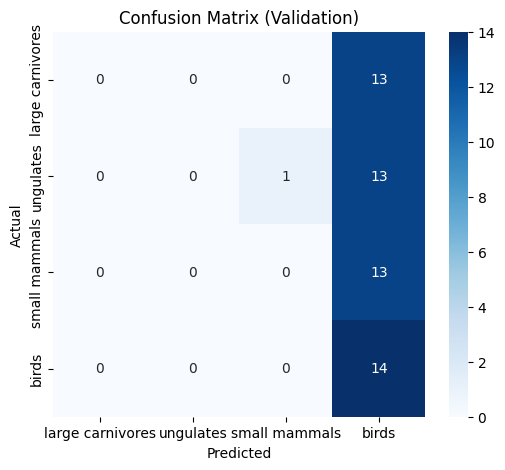

In [23]:
#validation confusion matrix

cm = confusion_matrix(all_labels, all_preds)

import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation)")
plt.show()

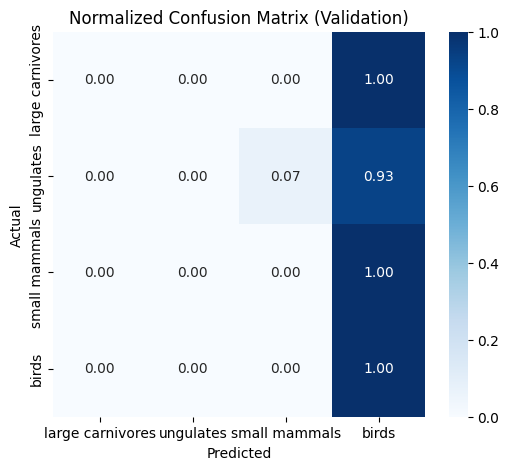

In [24]:
#normalized confusion matrix
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix (Validation)")
plt.show()



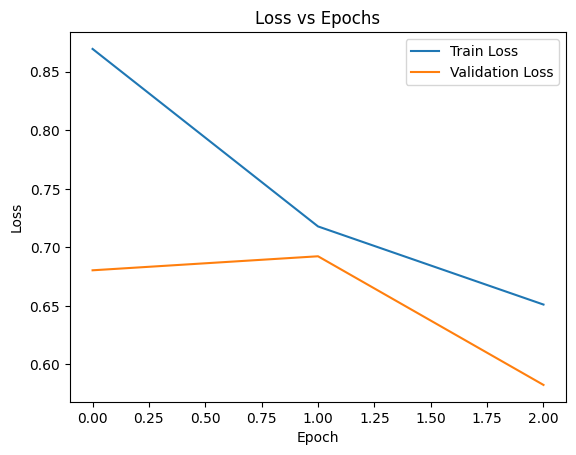

In [25]:
# train vs validation loss

import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.show()

In [26]:
# cm = confusion_matrix(all_labels, all_preds)

# import matplotlib.pyplot as plt

# plt.imshow(cm)
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.colorbar()

# plt.xticks(range(len(class_names)), class_names, rotation=45)
# plt.yticks(range(len(class_names)), class_names)

# plt.show()

In [27]:
#skeleton for final test confusion matrix

# model.eval()

# all_test_preds = []
# all_test_labels = []

# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.to(device)
#         labels = labels.to(device)

#         outputs = model(images)
#         preds = outputs.argmax(dim=1)

#         all_test_preds.extend(preds.cpu().numpy())
#         all_test_labels.extend(labels.cpu().numpy())

# precision = precision_score(all_test_labels, all_test_preds, average='weighted')
# recall = recall_score(all_test_labels, all_test_preds, average='weighted')
# f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
# accuracy = accuracy_score(all_test_labels, all_test_preds, average='weighted')

# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1 Score:", f1)

# cm = confusion_matrix(all_test_labels, all_test_preds)
# print(cm)

In [28]:
# look at what the model is composed of

#print(model)

In [29]:
# Checking for if model has turned off training parameters. You should only see weights and biases = true
# for name, param in model.named_parameters():
#     print(name, param.requires_grad)